# `pylcp` MOT convention sanity check

This notebook deliberately uses `pylcp.heuristiceq`, its minimal effective $F=0\rightarrow F'=1$ model. It checks conventions before any MgF Hamiltonian or molecular spectroscopy is introduced.

The model uses six built-in counter-propagating plane waves and `pylcp`'s quadrupole field $\mathbf B=\alpha(-x/2,-y/2,z)$.

In [1]:
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pylcp

print(f"pylcp version: {version('pylcp')}")

Matplotlib is building the font cache; this may take a moment.


pylcp version: 1.0.2


## Normalization and sign conventions

We set $\Gamma=1$ and $k=1$. Therefore `delta=-1` means red detuning $\Delta=-\Gamma$; velocity is in $\Gamma/k$; force is in $\hbar k\Gamma$; and the plotted position is the dimensionless coordinate for which the heuristic Zeeman shift is $\Gamma$ at $z=1$ when $\alpha=1$.

In `conventional3DMOTBeams`, `pol=+1` means right-circular polarization relative to each $z$-beam's own propagation direction; the built-in constructor assigns the transverse beam signs needed by its convention. The physical labels $\sigma^\pm$ depend on the quantization-axis convention, so this notebook tests the operational sign directly.

In [2]:
DELTA_OVER_GAMMA = -1.0
SATURATION_PER_BEAM = 1.0 / 6.0
GRADIENT = 1.0

def build_model(*, polarization_sign=+1, gradient_sign=+1):
    beams = pylcp.conventional3DMOTBeams(
        k=1.0,
        pol=polarization_sign,
        delta=DELTA_OVER_GAMMA,
        s=SATURATION_PER_BEAM,
    )
    field = pylcp.quadrupoleMagneticField(gradient_sign * GRADIENT)
    return pylcp.heuristiceq(beams, field, gamma=1.0, k=1.0)

def fz(model, *, z=0.0, vz=0.0):
    force, _ = model.force(
        np.array([0.0, 0.0, z]),
        np.array([0.0, 0.0, vz]),
        0.0,
    )
    return float(force[2])

def scan_position(model, z_values):
    return np.array([fz(model, z=z) for z in z_values])

def scan_velocity(model, velocity_values):
    return np.array([fz(model, vz=vz) for vz in velocity_values])

nominal = build_model()
flipped_polarization = build_model(polarization_sign=-1)
flipped_gradient = build_model(gradient_sign=-1)
flipped_both = build_model(polarization_sign=-1, gradient_sign=-1)

print('delta/Gamma =', DELTA_OVER_GAMMA)
print('force unit = hbar*k*Gamma')
print('velocity unit = Gamma/k')

delta/Gamma = -1.0
force unit = hbar*k*Gamma
velocity unit = Gamma/k


## 1. Position scan: $F_z(z)$ at $v_z=0$

For a restoring MOT, positive displacement must produce negative force and negative displacement positive force. Thus the slope through the origin should be negative.

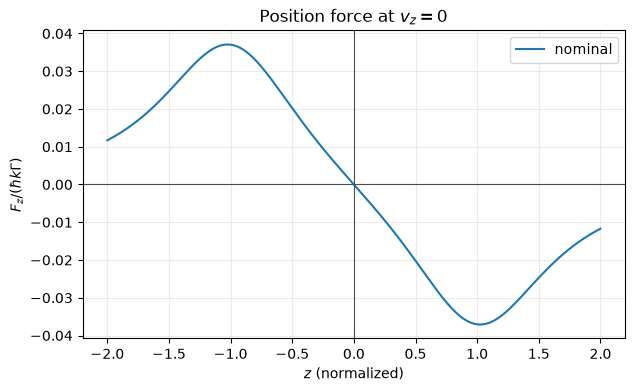

In [3]:
z = np.linspace(-2.0, 2.0, 401)
fz_z_nominal = scan_position(nominal, z)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, fz_z_nominal, label='nominal')
ax.axhline(0, color='0.3', linewidth=0.8)
ax.axvline(0, color='0.3', linewidth=0.8)
ax.set(xlabel=r'$z$ (normalized)', ylabel=r'$F_z/(\hbar k\Gamma)$', title=r'Position force at $v_z=0$')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 2. Velocity scan: $F_z(v_z)$ at $z=0$

Red detuning should damp near zero velocity: $v_z>0$ gives $F_z<0$, so the local velocity slope should be negative. At the field zero, flipping gradient or helicity does not change this ordinary Doppler-damping check.

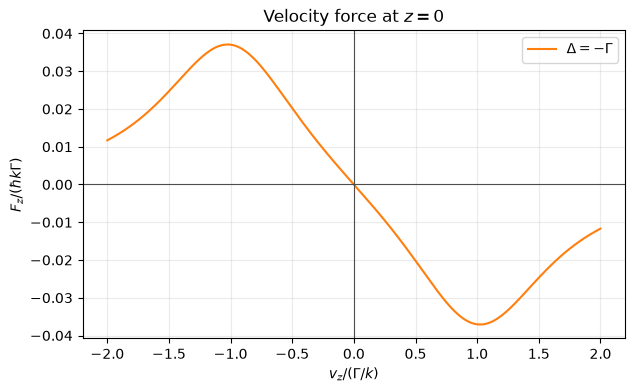

In [4]:
vz = np.linspace(-2.0, 2.0, 401)
fz_v_nominal = scan_velocity(nominal, vz)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(vz, fz_v_nominal, color='tab:orange', label=r'$\Delta=-\Gamma$')
ax.axhline(0, color='0.3', linewidth=0.8)
ax.axvline(0, color='0.3', linewidth=0.8)
ax.set(xlabel=r'$v_z/(\Gamma/k)$', ylabel=r'$F_z/(\hbar k\Gamma)$', title=r'Velocity force at $z=0$')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 3. Flip polarization only

With the field gradient fixed, reversing every beam's circular-polarization sign should reverse the Zeeman-dependent restoring force.

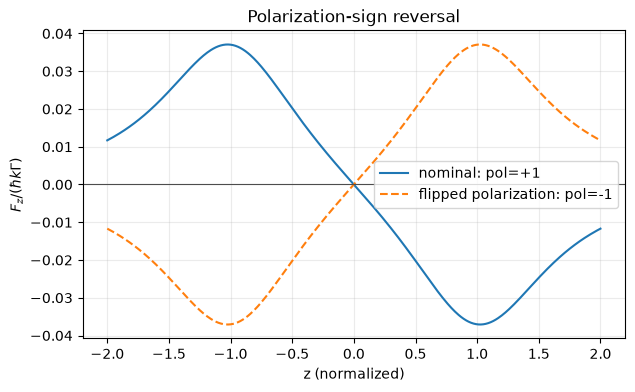

In [5]:
fz_z_flip_pol = scan_position(flipped_polarization, z)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, fz_z_nominal, label='nominal: pol=+1')
ax.plot(z, fz_z_flip_pol, '--', label='flipped polarization: pol=-1')
ax.axhline(0, color='0.3', linewidth=0.8)
ax.set(xlabel='z (normalized)', ylabel=r'$F_z/(\hbar k\Gamma)$', title='Polarization-sign reversal')
ax.legend(); ax.grid(alpha=0.25); plt.show()

## 4. Flip magnetic-field gradient only

Reversing $\alpha$ reverses the local quantization-axis/Zeeman-shift pattern while leaving the beams unchanged, so it should also reverse the restoring force.

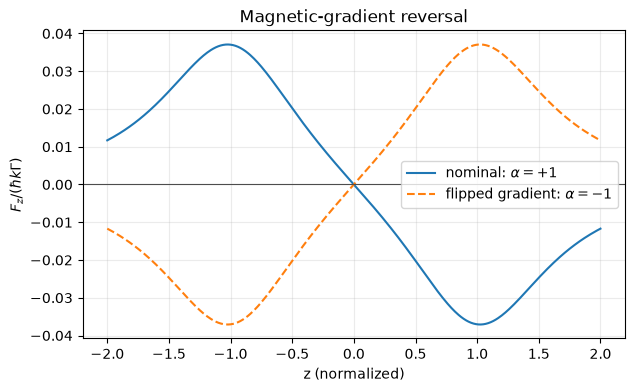

In [6]:
fz_z_flip_gradient = scan_position(flipped_gradient, z)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, fz_z_nominal, label=r'nominal: $\alpha=+1$')
ax.plot(z, fz_z_flip_gradient, '--', label=r'flipped gradient: $\alpha=-1$')
ax.axhline(0, color='0.3', linewidth=0.8)
ax.set(xlabel='z (normalized)', ylabel=r'$F_z/(\hbar k\Gamma)$', title='Magnetic-gradient reversal')
ax.legend(); ax.grid(alpha=0.25); plt.show()

## 5. Flip polarization and gradient together

The restoring force depends on their relative sign. Reversing both should therefore recover the nominal position-force curve.

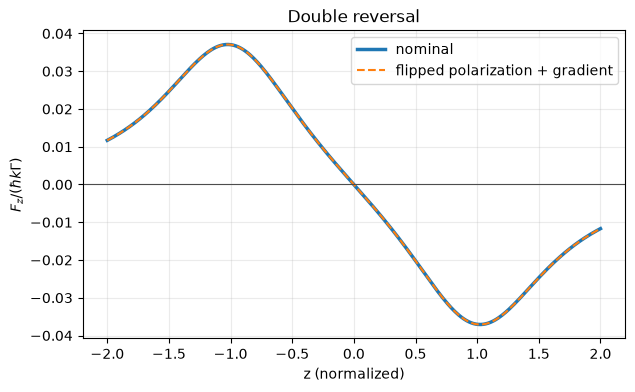

In [7]:
fz_z_flip_both = scan_position(flipped_both, z)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, fz_z_nominal, linewidth=2.5, label='nominal')
ax.plot(z, fz_z_flip_both, '--', label='flipped polarization + gradient')
ax.axhline(0, color='0.3', linewidth=0.8)
ax.set(xlabel='z (normalized)', ylabel=r'$F_z/(\hbar k\Gamma)$', title='Double reversal')
ax.legend(); ax.grid(alpha=0.25); plt.show()

## Quantitative acceptance checks

Local linear fits make the visual checks explicit. Negative $dF_z/dz$ is restoring and negative $dF_z/dv_z$ is damping. The single-flip slopes must be positive, while the double-flip curve must match nominal.

In [8]:
def local_slope(x, force, window=0.1):
    near_zero = np.abs(x) <= window
    return float(np.polyfit(x[near_zero], force[near_zero], 1)[0])

slopes = {
    'nominal dFz/dz': local_slope(z, fz_z_nominal),
    'nominal dFz/dvz': local_slope(vz, fz_v_nominal),
    'flipped polarization dFz/dz': local_slope(z, fz_z_flip_pol),
    'flipped gradient dFz/dz': local_slope(z, fz_z_flip_gradient),
    'flipped both dFz/dz': local_slope(z, fz_z_flip_both),
}
for name, value in slopes.items():
    print(f'{name:34s} = {value:+.6f}')

assert abs(fz(nominal)) < 1e-14
assert slopes['nominal dFz/dz'] < 0
assert slopes['nominal dFz/dvz'] < 0
assert slopes['flipped polarization dFz/dz'] > 0
assert slopes['flipped gradient dFz/dz'] > 0
assert slopes['flipped both dFz/dz'] < 0
np.testing.assert_allclose(fz_z_flip_both, fz_z_nominal, atol=1e-14, rtol=1e-12)
np.testing.assert_allclose(fz_z_flip_pol, -fz_z_nominal, atol=1e-14, rtol=1e-12)
np.testing.assert_allclose(fz_z_flip_gradient, -fz_z_nominal, atol=1e-14, rtol=1e-12)
print('All pylcp convention checks passed.')

nominal dFz/dz                     = -0.037136
nominal dFz/dvz                    = -0.037136
flipped polarization dFz/dz        = +0.037136
flipped gradient dFz/dz            = +0.037136
flipped both dFz/dz                = -0.037136
All pylcp convention checks passed.
